In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 71.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 13.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=26a6dc0474644b4f9fedced5c0f6f6d9503705c18c0eef2d8db05575a60b80c9
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

In [15]:
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt

simulator = BasicSimulator()
print('Ready!!')

Ready!!


In [16]:
def quantum_random_bit():
  qc = QuantumCircuit(1, 1)
  qc.h(0) # Hadamard gate
  qc.measure(0, 0) # Collapses to 0 or 1 with equal probability
  job = simulator.run(transpile(qc, simulator), shots=1, memory=True)
  return int(job.result().get_memory()[0])

def quantum_random_bits(n: int) -> list:
    return [quantum_random_bit() for _ in range(n)]

# Test
test_bits = quantum_random_bits(20)
print("Quantum random bits: ", test_bits)
print("Proportion of 1s: ", sum(test_bits)/len(test_bits))

Quantum random bits:  [0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
Proportion of 1s:  0.3


In [18]:
# Alice
# Encoding: bit=0,basis=0 -> |0>  bit=1,basis=0 -> |1>
#           bit=0,basis=1 -> |+>  bit=1,basis=1 -> |->
def alice_encode(bit: int, basis: int) -> QuantumCircuit:
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)       # Flip |0> -> |1>
    if basis == 1:
        qc.h(0)
    return qc

N = 100 # No of qubits Alices will send

alice_bits  = quantum_random_bits(N)   # Alice's secret bits
alice_bases = quantum_random_bits(N)   # Alice's encoding bases
alice_qubits = [alice_encode(alice_bits[i], alice_bases[i]) for i in range(N)]

print("Alice first 20 bits: ", alice_bits[:20])
print("Alice first 20 bases: ", alice_bases[:20])

Alice first 20 bits:  [0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1]
Alice first 20 bases:  [0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1]


In [5]:
# Oscar (Eavesdropper)
# Oscar picks his measurement basis using the same quantum RNG as Alice
# Since both are independent fair coin flips, Oscar matches Alice's basis 50% of the time
# When he guesses wrong, he measures a random result and resends the wrong state
# Bob then has a 50% chance of getting the wrong bit from that wrong state
# Net error rate: 0.5 (wrong basis) x 0.5 (wrong result) = 25% of sifted bits corrupted

INTERCEPTION_RATE = 1.0

def oscar_intercept(qubit_circuit: QuantumCircuit):
  oscar_basis = quantum_random_bit()   # Oscar's random basis guess

  # Oscar measures
  qc_measure = qubit_circuit.copy()
  if oscar_basis == 1:
      qc_measure.h(0)
  qc_measure.measure(0, 0)
  job = simulator.run(transpile(qc_measure, simulator), shots=1, memory=True)
  oscar_result = int(job.result().get_memory()[0])

  # Resends a fresh qubit based on what was measured
  qc_resend = QuantumCircuit(1, 1)
  if oscar_result == 1:
      qc_resend.x(0)
  if oscar_basis == 1:
      qc_resend.h(0)

  return qc_resend

intercepted_qubits = []
oscar_intervened = []
for i in range(N):
    if quantum_random_bit() < INTERCEPTION_RATE or INTERCEPTION_RATE == 1.0:
        intercepted_qubits.append(oscar_intercept(alice_qubits[i]))
        oscar_intervened.append(True)
    else:
        intercepted_qubits.append(alice_qubits[i])
        oscar_intervened.append(False)

print(f'Oscar intercepted: {sum(oscar_intervened)}/{N} qubits ({INTERCEPTION_RATE*100:.0f}% rate)')


Oscar intercepted: 100/100 qubits (100% rate)


In [19]:
# Bob
# No knowledge of Alice's choices, matching basis -> correct bit guaranteed
# Wrong basis -> random result, discarded
def bob_measure(qubit_circuit: QuantumCircuit, basis: int):
    qc = qubit_circuit.copy()
    if basis == 1:
        qc.h(0)       # Rotate back from X basis before measuring
    qc.measure(0, 0)
    job = simulator.run(transpile(qc, simulator), shots=1, memory=True)
    return int(job.result().get_memory()[0])

bob_bases = quantum_random_bits(N)
bob_results = [bob_measure(intercepted_qubits[i], bob_bases[i]) for i in range(N)]

print("Bob first 20 bases: ", bob_bases[:20])
print("Bob first 20 results: ", bob_results[:20])

Bob first 20 bases:  [0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
Bob first 20 results:  [0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0]


In [20]:
# Bob and Alice unaware of interception
# Key sifting = keep only bits where both use the same basis
def sift_key(alice_bits, alice_bases, bob_results, bob_bases):
    sifted_alice, sifted_bob = [], []
    for i in range(len(alice_bits)):
        if alice_bases[i] == bob_bases[i]:
            sifted_alice.append(alice_bits[i])
            sifted_bob.append(bob_results[i])
    return sifted_alice, sifted_bob

sifted_alice, sifted_bob = sift_key(
    alice_bits, alice_bases, bob_results, bob_bases
)

print("Number of qubits sent: ", N)
print("Sifted key length: ", len(sifted_alice))
print("Alice sifted key (first 20): ", sifted_alice)
print("Bob sifted key (first 20): ", sifted_bob)
print(f"Are the keys identical? {sifted_alice == sifted_bob}!")

Number of qubits sent:  100
Sifted key length:  57
Alice sifted key (first 20):  [0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1]
Bob sifted key (first 20):  [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0]
Are the keys identical? False!


In [21]:
# Detection of attack
# Both Alice and Bob sacrifice a portion of their sifted key and compare
DETECTION_THRESHOLD = 0.10
SAMPLE_FRACTION     = 0.50

n_check     = int(len(sifted_alice) * SAMPLE_FRACTION)
check_alice = sifted_alice[:n_check]
check_bob   = sifted_bob[:n_check]
final_alice = sifted_alice[n_check:]
final_bob   = sifted_bob[n_check:]

mismatches = sum(a != b for a, b in zip(check_alice, check_bob))
qber = mismatches / n_check if n_check > 0 else 0.0

print("Bits used for QBER check: ", n_check)
print("Mismatches found: ", mismatches)
print("QBER: ", round(qber * 100, 2), "%")
print("Detection threshold: ", DETECTION_THRESHOLD * 100, "%")
print()

if qber > DETECTION_THRESHOLD:
    print("ATTACK DETECTED! QBER exceeds threshold. Aborting key exchange.")
    print("Expected ~25% with full intercept-resend. Got", round(qber * 100, 1), "%.")
else:
    print("No attack detected. Try again.")

Bits used for QBER check:  28
Mismatches found:  14
QBER:  50.0 %
Detection threshold:  10.0 %

ATTACK DETECTED! QBER exceeds threshold. Aborting key exchange.
Expected ~25% with full intercept-resend. Got 50.0 %.


Running trials across interception rates...
Rate: 0.0   Mean QBER: 0.0
Rate: 0.1   Mean QBER: 0.0335
Rate: 0.2   Mean QBER: 0.0411
Rate: 0.3   Mean QBER: 0.1113
Rate: 0.4   Mean QBER: 0.1313
Rate: 0.5   Mean QBER: 0.195
Rate: 0.6   Mean QBER: 0.1908
Rate: 0.7   Mean QBER: 0.1933
Rate: 0.8   Mean QBER: 0.2221
Rate: 0.9   Mean QBER: 0.2142
Rate: 1.0   Mean QBER: 0.3122


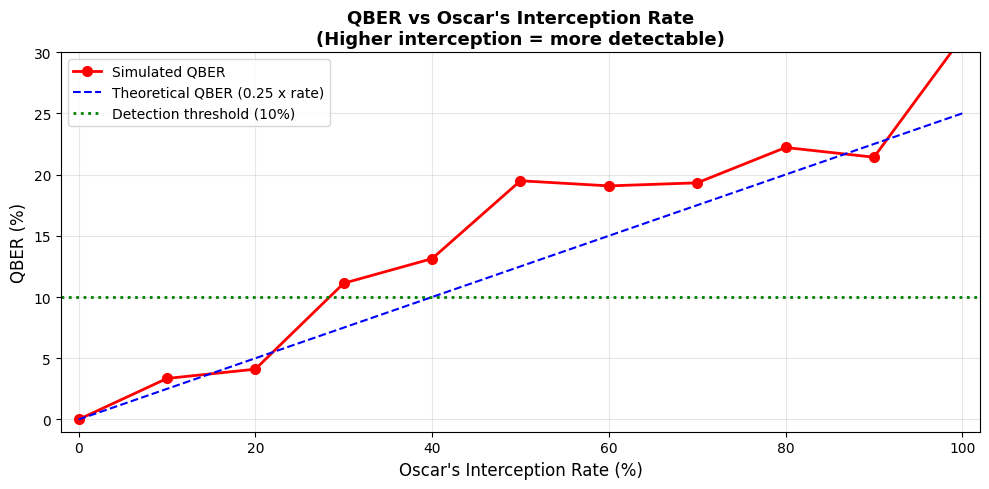

In [25]:
def quantum_random_rate_check(interception_rate: float) -> bool:
    # Generate a quantum random number 0-9 using 4 quantum bits
    # Intercept if the number falls below the interception rate threshold
    sample = sum(quantum_random_bit() * (2**i) for i in range(4)) % 10
    return sample < int(interception_rate * 10)

def run_attack_trial(n_qubits: int, interception_rate: float):
    # Runs a full BB84 trial at a given interception rate and returns the QBER
    # Used to plot how detectable Oscar is across different interception rates
    a_bits  = quantum_random_bits(n_qubits)
    a_bases = quantum_random_bits(n_qubits)
    b_bases = quantum_random_bits(n_qubits)

    qubits = [alice_encode(a_bits[i], a_bases[i]) for i in range(n_qubits)]

    channel = []
    for i in range(n_qubits):
        if interception_rate == 1.0 or quantum_random_rate_check(interception_rate):
            channel.append(oscar_intercept(qubits[i]))
        else:
            channel.append(qubits[i])

    b_results = [bob_measure(channel[i], b_bases[i]) for i in range(n_qubits)]
    sa, sb    = sift_key(a_bits, a_bases, b_results, b_bases)

    if len(sa) < 2:
        return 0.0

    n_check    = int(len(sa) * 0.5)
    mismatches = sum(a != b for a, b in zip(sa[:n_check], sb[:n_check]))
    return mismatches / n_check if n_check > 0 else 0.0

interception_rates = [i/10 for i in range(0, 11)]
n_trials = 5
mean_qbers = []

print("Running trials across interception rates...")
for rate in interception_rates:
    trials = [run_attack_trial(100, rate) for _ in range(n_trials)]
    mean_qbers.append(np.mean(trials))
    print("Rate:", rate, "  Mean QBER:", round(np.mean(trials), 4))

theoretical = [0.25 * r for r in interception_rates]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot([r*100 for r in interception_rates],
        [q*100 for q in mean_qbers],
        'ro-', linewidth=2, markersize=7, label='Simulated QBER')
ax.plot([r*100 for r in interception_rates],
        [q*100 for q in theoretical],
        'b--', linewidth=1.5, label='Theoretical QBER (0.25 x rate)')
ax.axhline(DETECTION_THRESHOLD*100, color='green', linestyle=':',
           linewidth=2, label="Detection threshold (10%)")

ax.set_xlabel("Oscar's Interception Rate (%)", fontsize=12)
ax.set_ylabel("QBER (%)", fontsize=12)
ax.set_title("QBER vs Oscar's Interception Rate\n(Higher interception = more detectable)",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(-2, 102)
ax.set_ylim(-1, 30)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

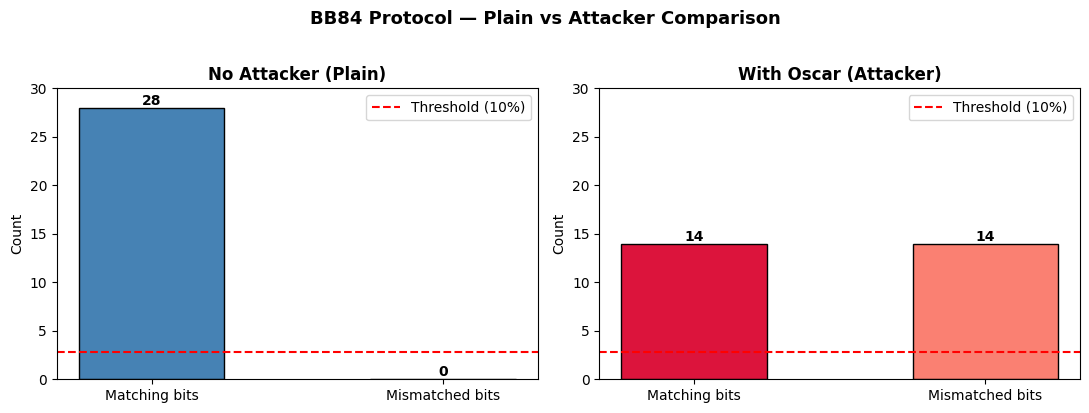

In [27]:
# Final visualisation
plain_mismatches  = 0
attack_mismatches = mismatches

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (title, matched, mismatched, color) in zip(axes, [
    ("No Attacker (Plain)",  n_check, plain_mismatches,  "steelblue"),
    ("With Oscar (Attacker)", n_check - attack_mismatches, attack_mismatches, "crimson"),
]):
    bars = ax.bar(["Matching bits", "Mismatched bits"],
                  [matched, mismatched],
                  color=[color, "salmon"], edgecolor="black", width=0.5)
    ax.axhline(n_check * DETECTION_THRESHOLD, color="red",
               linestyle="--", linewidth=1.5,
               label="Threshold (10%)")
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_ylabel("Count")
    ax.set_ylim(0, n_check + 2)
    ax.legend()
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                str(int(h)), ha="center", fontweight="bold")

plt.suptitle("BB84 Protocol — Plain vs Attacker Comparison",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()